<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What is an Image</b>
</h1>
<div style="font-family:'Times New Roman';">
An image is really just a grid of numbers. Each number is a pixel and tells how bright that little spot is, from 0 (black) up to 255 (white). A grayscale image is one such grid, a colour image is three grids (red, green, blue) stacked together. This notebook actualy looks at those numbers and the diffrent types of images.
</div>

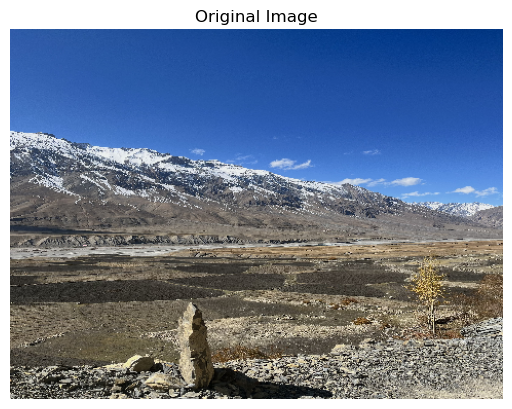

shape (360, 480, 3)  dtype uint8  min 0  max 255


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load my own photo and shrink it, the original is huge (4032x3024)
img = cv2.imread('image.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (480, 360))

plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()
print('shape', img.shape, ' dtype', img.dtype, ' min', img.min(), ' max', img.max())

## an image is a grid of numbers

to prove it, lets zoom into a tiny 8x8 patch of the grayscale image and print the actual pixel values sitting inside it.

grayscale shape (360, 480)


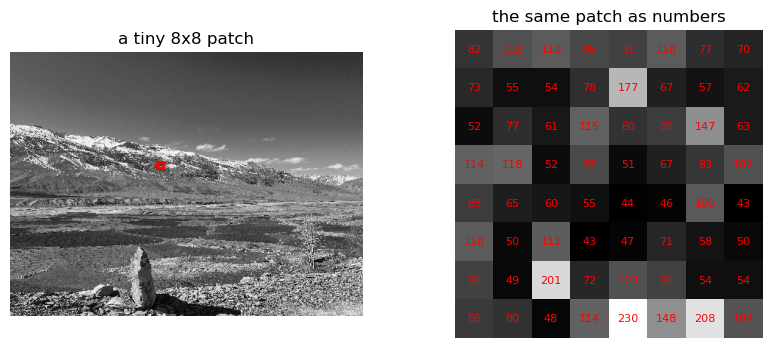

In [2]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
print('grayscale shape', gray.shape)   # 2d now, just one number per pixel

y, x = 150, 200
patch = gray[y:y+8, x:x+8]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(gray, cmap='gray')
ax[0].add_patch(plt.Rectangle((x, y), 8, 8, edgecolor='red', facecolor='none', lw=2))
ax[0].set_title('a tiny 8x8 patch'); ax[0].axis('off')

ax[1].imshow(patch, cmap='gray')
for i in range(8):
    for j in range(8):
        ax[1].text(j, i, patch[i, j], ha='center', va='center', color='red', fontsize=8)
ax[1].set_title('the same patch as numbers'); ax[1].axis('off')
plt.show()

## bit depth and intensity

these are **8 bit** images, so every pixel is a whole number from 0 to 255. a histogram shows how many pixels sit at each intensity, basicaly the spread of dark vs bright.

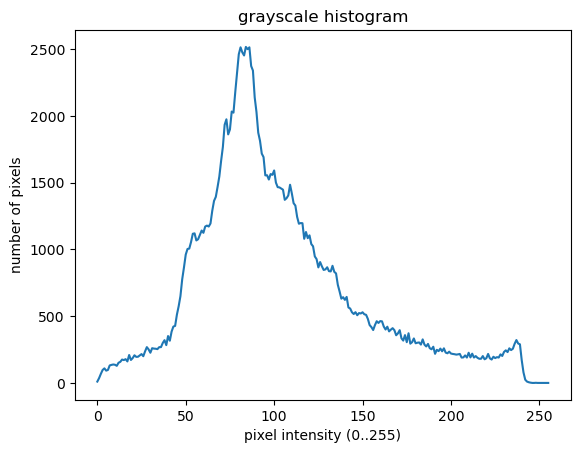

In [6]:
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
plt.plot(hist)
plt.title('grayscale histogram')
plt.xlabel('pixel intensity (0..255)')
plt.ylabel('number of pixels')
plt.show()

## the three common types

- **colour** : 3 channels (R, G, B), so shape is (h, w, 3)
- **grayscale** : 1 channel, shape (h, w), just brightness
- **binary** : only two values, 0 or 255, made by thresholding the grayscale

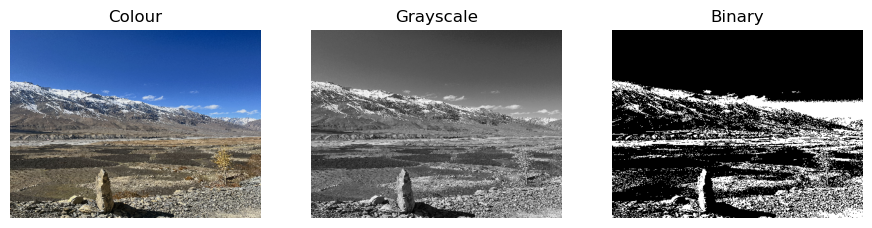

In [11]:
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(11, 4))
plt.subplot(1, 3, 1); plt.imshow(img);            plt.title('Colour');    plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(gray, cmap='gray');   plt.title('Grayscale'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(binary, cmap='gray'); plt.title('Binary');    plt.axis('off')
plt.show()

## a colour image is 3 channels

splitting the colour image gives the red, green and blue grids. shown in gray, a bright spot means that channel is strong there.

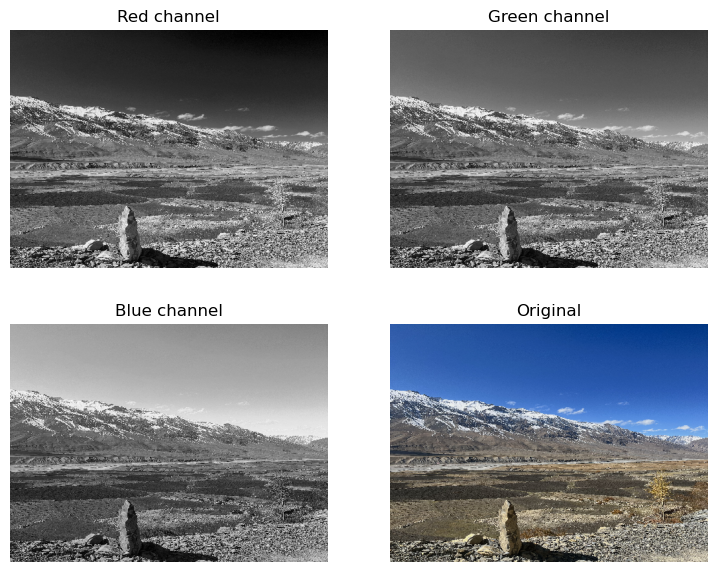

In [8]:
R, G, B = cv2.split(img)

plt.figure(figsize=(9, 7))
plt.subplot(2, 2, 1); plt.imshow(R, cmap='gray'); plt.title('Red channel');   plt.axis('off')
plt.subplot(2, 2, 2); plt.imshow(G, cmap='gray'); plt.title('Green channel'); plt.axis('off')
plt.subplot(2, 2, 3); plt.imshow(B, cmap='gray'); plt.title('Blue channel');  plt.axis('off')
plt.subplot(2, 2, 4); plt.imshow(img);            plt.title('Original');      plt.axis('off')
plt.show()

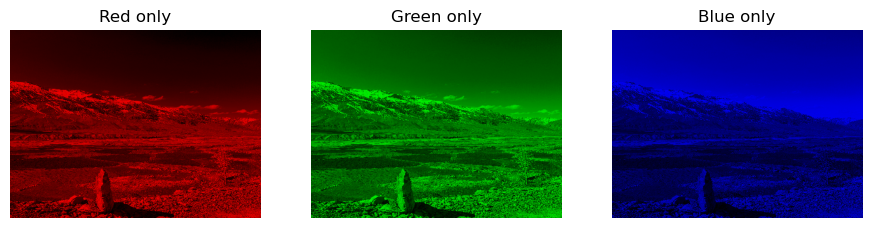

In [9]:
# keeping only one channel and zeroing the others
zero = np.zeros_like(R)
red_only   = cv2.merge([R, zero, zero])
green_only = cv2.merge([zero, G, zero])
blue_only  = cv2.merge([zero, zero, B])

plt.figure(figsize=(11, 4))
plt.subplot(1, 3, 1); plt.imshow(red_only);   plt.title('Red only');   plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(green_only); plt.title('Green only'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(blue_only);  plt.title('Blue only');  plt.axis('off')
plt.show()

### recap

an image is just numbers in a grid. grayscale is one grid, colour is three. everything we do next (enhancement, segmentation, augmentation, even the CNN) is just math on these numbers.